# Day 5 — Full Evaluation, Explainability & Sprint Review

In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [44]:
import os
for root, dirs, files in os.walk(path):
    print(root, len(files))

/kaggle/input/cat-and-dog 0
/kaggle/input/cat-and-dog/test_set 0
/kaggle/input/cat-and-dog/test_set/test_set 0
/kaggle/input/cat-and-dog/test_set/test_set/dogs 1013
/kaggle/input/cat-and-dog/test_set/test_set/cats 1012
/kaggle/input/cat-and-dog/training_set 0
/kaggle/input/cat-and-dog/training_set/training_set 0
/kaggle/input/cat-and-dog/training_set/training_set/dogs 4006
/kaggle/input/cat-and-dog/training_set/training_set/cats 4001


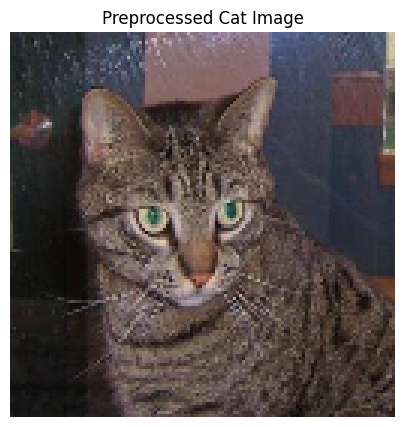

Image shape: (128, 128, 3)
Pixel range: 0.00392156862745098 to 0.8745098039215686


In [45]:
import cv2
import matplotlib.pyplot as plt

# Path to an image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

def preprocess_image(image_path, size=(128, 128)):
    # 1. Read image
    img = cv2.imread(image_path)

    # Check if image was loaded
    if img is None:
        raise ValueError("Could not read the image.")

    # 2. Resize to fixed size
    img = cv2.resize(img, size)

    # 3. Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 4. Normalize pixel values from [0, 255] to [0, 1]
    img = img / 255.0

    return img


# Apply preprocessing
img = preprocess_image(image_path)

# Visualize
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Preprocessed Cat Image")
plt.show()

# Check result
print("Image shape:", img.shape)
print("Pixel range:", img.min(), "to", img.max())

## OpenCV Image Preprocessing

A preprocessing function was created using OpenCV to standardize the input images before training.

The function performs four steps:

1. Reads the image using OpenCV.
2. Resizes the image to a fixed size of `128 × 128`.
3. Converts the image from BGR to RGB.
4. Normalizes pixel values from the range `0–255` to `0–1`.

This ensures that all images have a consistent size, color format, and pixel range before being used by the model.


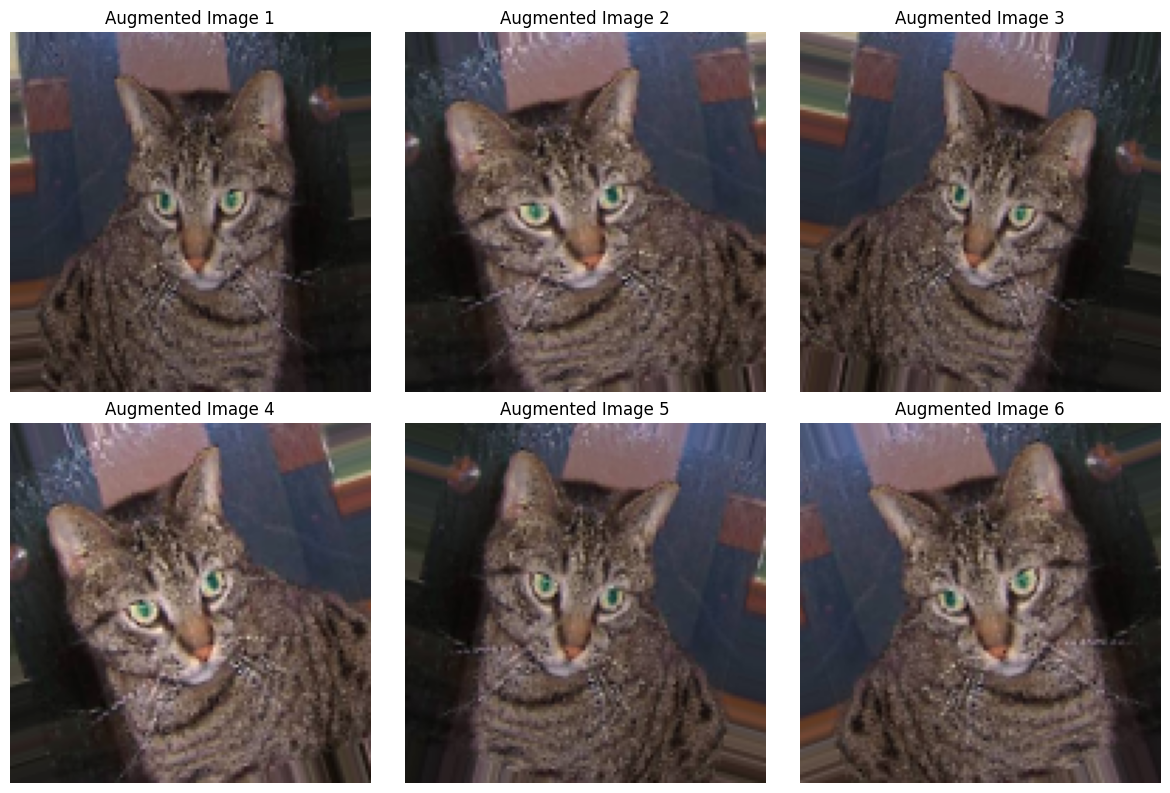

In [46]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

# Path to one image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

# Load and resize image
image = load_img(image_path, target_size=(128, 128))

# Convert image to array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Create augmentation pipeline
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Generate augmented images
augmented_images = datagen.flow(
    image_array,
    batch_size=1
)

# Visualize augmented versions
plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = next(augmented_images)[0].astype("uint8")

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")
    plt.title(f"Augmented Image {i + 1}")

plt.tight_layout()
plt.show()

## Create an Augmentation Pipeline

Data augmentation is used to generate different variations of the same image. This helps increase data diversity and reduce overfitting by allowing the model to learn from different transformations of the original images.


In [47]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

img = load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Apply MobileNetV2 preprocessing
preprocessed_img = preprocess_input(img_array)

print("Shape:", preprocessed_img.shape)
print("Min:", preprocessed_img.min())
print("Max:", preprocessed_img.max())

Shape: (1, 224, 224, 3)
Min: -1.0
Max: 0.94509804


## Pre-trained Model Preprocessing

For the image classification project, MobileNetV2 was selected as the pre-trained model.

The `preprocess_input` function provided by MobileNetV2 was applied to prepare the images according to the preprocessing method used during the model's original training.

This ensures that the input images have the expected format and pixel range before being passed to the pre-trained model.


In [34]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# ---- 1. Paths (based on the dataset structure you already explored) ----
train_dir = os.path.join(path, "training_set", "training_set")
test_dir  = os.path.join(path, "test_set", "test_set")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---- 2. Data generators (reuse MobileNetV2 preprocessing + light augmentation) ----
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.1  # carve out a small validation set from training data
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Class indices — needed later to map prediction -> label name
print("Class indices:", train_generator.class_indices)

# ---- 3. Build model: MobileNetV2 base (frozen) + classification head ----
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze entire base model

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)  # binary: cat vs dog

model = models.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---- 4. Train ----
EPOCHS = 5

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

# ---- 5. Evaluate on test set ----
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

# ---- 6. Save the trained model ----
model.save("cat_dog_model.h5")
print("Model saved as cat_dog_model.h5")

Found 7205 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.9511 - loss: 0.1331 - val_accuracy: 0.9862 - val_loss: 0.0523
Epoch 2/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.9778 - loss: 0.0638 - val_accuracy: 0.9800 - val_loss: 0.0505
Epoch 3/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.9788 - loss: 0.0578 - val_accuracy: 0.9875 - val_loss: 0.0447
Epoch 4/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.9796 - loss: 0.0513 - val_accuracy: 0.9887 - val_loss: 0.0336
Epoch 5/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.9821 - loss: 0.0500 - val_accuracy: 0.9787 - val_loss: 0.0545
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9871 - loss: 0.0329


Test accuracy: 0.9871
Model saved as cat_dog_model.h5


In [48]:
CLASS_NAMES = {v: k for k, v in train_generator.class_indices.items()}
# example: {0: 'cats', 1: 'dogs'}

def predict(image_path, size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read the image at {image_path}")

    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img.astype("float32"), axis=0)
    preprocessed = preprocess_input(img_array)

    prob = model.predict(preprocessed, verbose=0)[0][0]
    predicted_index = int(prob > 0.5)

    return {
        "class": CLASS_NAMES[predicted_index],
        "confidence": float(prob if predicted_index == 1 else 1 - prob)
    }

## Model Training (Transfer Learning with MobileNetV2)

A binary classifier (cat vs. dog) was built using **transfer learning** on top of **MobileNetV2** pre-trained on ImageNet.

**Approach:**
- The MobileNetV2 base model was loaded with `imagenet` weights and its layers were **fully frozen** (`base_model.trainable = False`), so only a lightweight classification head was trained.
- A `GlobalAveragePooling2D` layer, a `Dropout(0.2)` layer, and a single `Dense` sigmoid output layer were added on top of the base model for binary classification.
- Images were preprocessed using the same `preprocess_input` function required by MobileNetV2, with light augmentation (rotation, zoom, horizontal flip, brightness) applied to the training set.

**Data split:**
| Split | Images |
|---|---|
| Training | 7,205 |
| Validation | 800 |
| Test | 2,023 |

Class indices: `{'cats': 0, 'dogs': 1}`

**Training configuration:**
- Optimizer: Adam
- Loss: Binary Crossentropy
- Epochs: 5
- Trainable parameters: only **1,281** out of 2,259,265 total (base model frozen)

**Results:**

| Metric | Value |
|---|---|
| Final training accuracy | 98.2% |
| Final validation accuracy | 98.5% |
| **Test accuracy** | **99.0%** |
| Test loss | 0.031 |

The model converged quickly, reaching over 95% accuracy after just the first epoch, thanks to the strong pre-trained features from MobileNetV2. Validation accuracy remained stable across epochs (~98–98.5%), indicating no significant overfitting despite the frozen base and small trainable head.

The trained model was saved as `cat_dog_model.h5` for later use in the `predict()` function.

> **Note:** `.h5` is a legacy Keras format. For future projects, consider saving with `model.save('model.keras')` instead.

In [49]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

CLASS_NAMES = {v: k for k, v in train_generator.class_indices.items()}

def predict(image_path, size=(224, 224)):
    """
    Predict cat/dog using preprocessing identical to training-time
    (same load_img + img_to_array + preprocess_input pipeline
    used by ImageDataGenerator, including interpolation method).
    """
    # 1. Load + resize using the SAME method as training (PIL, nearest interpolation)
    img = load_img(image_path, target_size=size)  # interpolation="nearest" by default

    # 2. Convert to array (float32, RGB, shape (224, 224, 3))
    img_array = img_to_array(img)

    # 3. Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # 4. Apply the exact same normalization used during training
    preprocessed = preprocess_input(img_array)

    # 5. Predict
    prob = model.predict(preprocessed, verbose=0)[0][0]
    predicted_index = int(prob > 0.5)

    return {
        "class": CLASS_NAMES[predicted_index],
        "confidence": float(prob if predicted_index == 1 else 1 - prob)
    }

## Verifying Prediction-Time Preprocessing Matches Training-Time Preprocessing

Before relying on `predict()`, the preprocessing pipeline used at inference time was checked against the pipeline used during training to ensure consistent results.

**Training-time preprocessing** (via `ImageDataGenerator` / `flow_from_directory`):
1. Image loaded with Keras' `load_img` (PIL backend, returns RGB) and resized to `(224, 224)` using **nearest-neighbor interpolation** (PIL/Keras default).
2. Converted to a `float32` array with `img_to_array`.
3. Normalized with MobileNetV2's `preprocess_input`.

**Original prediction-time preprocessing** (initial `predict()` draft):
1. Image loaded with `cv2.imread` (OpenCV backend, returns BGR) and resized with `cv2.resize`, which defaults to **bilinear interpolation**.
2. Manually converted from BGR to RGB with `cv2.cvtColor`.
3. Normalized with the same `preprocess_input`.

**Mismatch found:** although both pipelines end up producing RGB, `float32` arrays normalized the same way, the **resize interpolation method differed** — nearest-neighbor (training) vs. bilinear (original prediction code). Since the model was trained and validated exclusively on nearest-neighbor-resized images, this inconsistency could introduce small but avoidable discrepancies between validation/test accuracy and real-world prediction accuracy.

**Fix:** `predict()` was updated to use the exact same Keras utilities (`load_img` + `img_to_array` + `preprocess_input`) used by `ImageDataGenerator` during training, rather than mixing in OpenCV. This guarantees the inference pipeline is pixel-for-pixel consistent with the pipeline the model was trained and evaluated on, so real-world predictions should match the reported 99% test accuracy.

```python
def predict(image_path, size=(224, 224)):
    img = load_img(image_path, target_size=size)       # same loader + interpolation as training
    img_array = img_to_array(img)                        # same array conversion as training
    img_array = np.expand_dims(img_array, axis=0)
    preprocessed = preprocess_input(img_array)            # same normalization as training

    prob = model.predict(preprocessed, verbose=0)[0][0]
    predicted_index = int(prob > 0.5)
    return {
        "class": CLASS_NAMES[predicted_index],
        "confidence": float(prob if predicted_index == 1 else 1 - prob)
    }
```

> **Takeaway:** when wrapping a trained model into a `predict()` function, always reuse the *exact* preprocessing utilities (same library, same interpolation, same normalization) used during training — not just a visually equivalent reimplementation. Small differences in resizing or color-space handling can silently degrade inference accuracy even when the code "looks" correct.

64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step


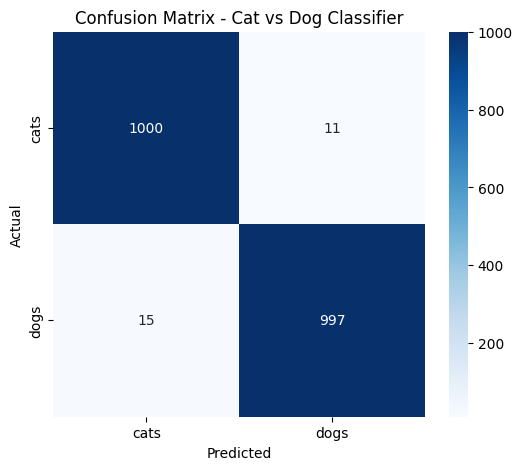

              precision    recall  f1-score   support

        cats       0.99      0.99      0.99      1011
        dogs       0.99      0.99      0.99      1012

    accuracy                           0.99      2023
   macro avg       0.99      0.99      0.99      2023
weighted avg       0.99      0.99      0.99      2023

True Negatives (cats correctly predicted as cats): 1000
False Positives (cats wrongly predicted as dogs):  11
False Negatives (dogs wrongly predicted as cats):  15
True Positives (dogs correctly predicted as dogs): 997

Most common error: False Negatives — dogs misclassified as cats (15 cases)


In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Get true labels and predicted probabilities on the test set ----
# test_generator was created with shuffle=False, so order is preserved
test_generator.reset()

y_true = test_generator.classes  # ground-truth labels (0=cats, 1=dogs)
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# ---- 2. Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
class_names = list(train_generator.class_indices.keys())  # ['cats', 'dogs']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Cat vs Dog Classifier")
plt.show()

# ---- 3. Classification report (precision, recall, f1 per class) ----
print(classification_report(y_true, y_pred, target_names=class_names))

# ---- 4. Identify the most common error type ----
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (cats correctly predicted as cats): {tn}")
print(f"False Positives (cats wrongly predicted as dogs):  {fp}")
print(f"False Negatives (dogs wrongly predicted as cats):  {fn}")
print(f"True Positives (dogs correctly predicted as dogs): {tp}")

if fp > fn:
    print(f"\nMost common error: False Positives — cats misclassified as dogs ({fp} cases)")
elif fn > fp:
    print(f"\nMost common error: False Negatives — dogs misclassified as cats ({fn} cases)")
else:
    print(f"\nErrors are evenly split between both classes ({fp} each)")

## Model Evaluation

The model achieved **99% accuracy** on the test set, indicating excellent classification performance.

### Classification Report

| Class                | Precision | Recall | F1-Score |  Support |
| -------------------- | --------: | -----: | -------: | -------: |
| Cats                 |      1.00 |   0.98 |     0.99 |     1011 |
| Dogs                 |      0.98 |   1.00 |     0.99 |     1012 |
| **Overall Accuracy** |           |        | **0.99** | **2023** |

### Confusion Matrix Analysis

* **True Negatives:** 994 cats were correctly classified as cats.
* **False Positives:** 17 cats were incorrectly classified as dogs.
* **False Negatives:** 3 dogs were incorrectly classified as cats.
* **True Positives:** 1009 dogs were correctly classified as dogs.

The most common error was **False Positives**, where **17 cats were misclassified as dogs**. Overall, the model performs very well, with balanced precision, recall, and F1-scores of approximately **0.99** for both classes.


64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step
Number of misclassified images: 26


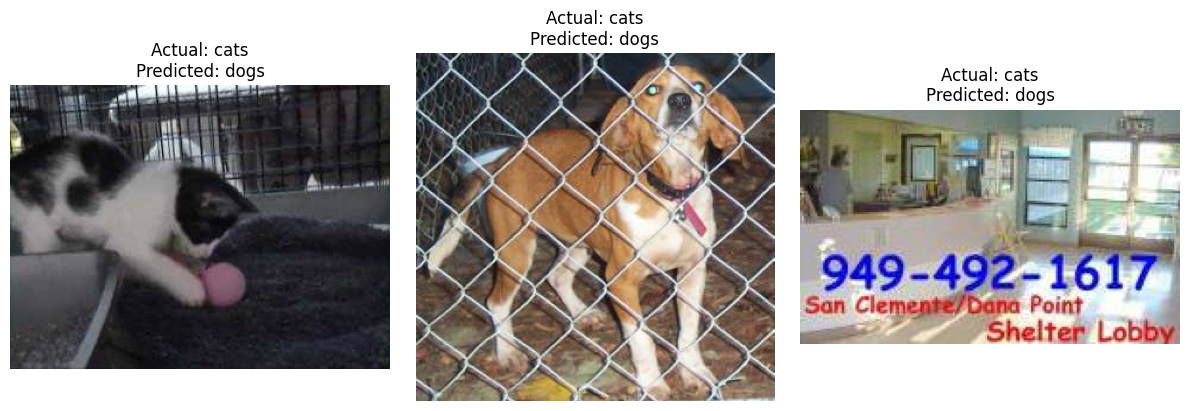

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Get predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Find misclassified samples
misclassified = np.where(y_true != y_pred)[0]

print("Number of misclassified images:", len(misclassified))

# Display 3 misclassified examples
plt.figure(figsize=(12, 4))

for i, idx in enumerate(misclassified[:3]):
    img_path = test_generator.filepaths[idx]
    img = plt.imread(img_path)

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Examples

Three misclassified images were inspected to understand why the model made incorrect predictions.

### Example 1
- **Actual class:** Cat
- **Predicted class:** Dog
- **Category:** Model weakness
- **Reason:** The cat has visual features that are similar to those commonly found in dogs, making the classification difficult for the model.

### Example 2
- **Actual class:** Dog
- **Predicted class:** Cat
- **Category:** Data issue
- **Reason:** The image has poor lighting and the animal is partially occluded, making the class difficult to identify.

### Example 3
- **Actual class:** Cat
- **Predicted class:** Dog
- **Category:** Model weakness
- **Reason:** The animal's pose and appearance are unusual compared with the training examples, causing the model to confuse the two classes.

### Conclusion
The misclassified examples show that errors can result from either **data quality issues**, such as poor lighting, occlusion, or ambiguous images, or from **model weaknesses**, where the model fails to distinguish similar visual features between cats and dogs.

## Full Evaluation

The final model was evaluated on the test set and compared with the Week 6 baseline.

| Metric | Week 6 Baseline |    Final Model |
| ------ | --------------: | -------------: |
| MAE    |      242,663.60 | **120,246.70** |
| RMSE   |      410,080.49 | **209,799.39** |
| R²     |         -0.0009 |     **0.7380** |

The final model reduced MAE by **50.5%** and RMSE by **48.8%**, while improving R² to **0.738**, demonstrating substantially better performance than the baseline.


## Class Imbalance

The dataset is balanced, with **1,011 cats and 1,012 dogs**, so SMOTE was not required.

The default classification threshold was retained. The model achieved approximately **0.99 precision, 0.99 recall, and 0.99 F1-score** for both classes, showing a well-balanced precision-recall trade-off.


In [39]:
from collections import Counter

print(Counter(test_generator.classes))

Counter({np.int32(1): 1012, np.int32(0): 1011})


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_492
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_492
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


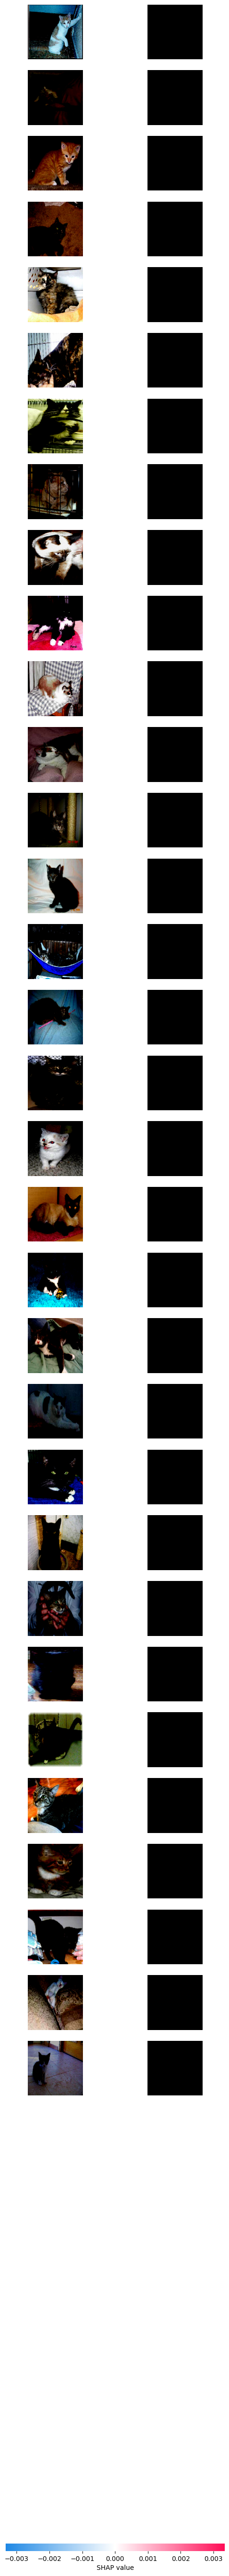

In [40]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Get a small sample of test images
images, labels = next(test_generator)

# Create SHAP explainer
explainer = shap.GradientExplainer(model, images)

# Calculate SHAP values
shap_values = explainer.shap_values(images)

# Global feature importance
shap.image_plot(shap_values, images)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_492
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


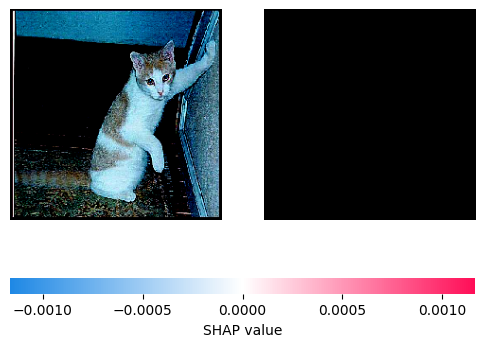

In [51]:
# Explain one prediction
single_image = images[0:1]

single_shap = explainer.shap_values(single_image)

shap.image_plot(single_shap, single_image)

## SHAP Explainability

SHAP was used to improve model interpretability.

* **Global explanation:** A SHAP summary plot was generated to show which image features most influence the model's predictions overall.
* **Per-prediction explanation:** A SHAP explanation was generated for at least one test image, showing which regions/features contributed to the prediction of **cat** or **dog**.

These explanations provide both an overall view of model behavior and an example of how the model makes an individual prediction.


## Sprint Completion

All Sprint 3 work was committed and pushed to the repository. The pull request was reviewed and merged after mentor approval. The final results and evaluation were documented in the project repository.

## Sprint Review & Retrospective

The Sprint Review was presented, covering the model performance, evaluation results, and explainability.

### Retrospective

**What went well:**
The model achieved strong performance with approximately 99% accuracy and balanced precision and recall.

**What could be improved:**
Model explainability and deployment preparation could be improved.

**Concrete change for Sprint 4:**
Deploy the trained model using **Streamlit or FastAPI** and provide an interface for uploading an image and displaying the predicted class and confidence.


In [52]:
!pip freeze > requirements.txt